In [1]:
import chromadb
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from datetime import datetime
import os

# Use the multimodal embedding function (CLIP handles images)
embedding_function = OpenCLIPEmbeddingFunction()
data_loader = ImageLoader()

client = chromadb.Client()

collection = client.get_or_create_collection(
    name="Pet_Image_Collection",
    embedding_function=embedding_function,
    data_loader=data_loader,
    metadata={
        "description": "A collection of dog and cat images",
        "created": str(datetime.now())
    }
)

# Get all image paths from image_set_1/
image_dir = "image_set_1"
image_files = [f for f in os.listdir(image_dir) if f.endswith((".jpg", ".png"))]
image_paths = [os.path.join(image_dir, f) for f in image_files]

# Add images using URIs — ChromaDB loads and embeds them automatically
collection.add(
    ids=[os.path.splitext(f)[0] for f in image_files],   # e.g. "corgi", "husky"
    uris=image_paths,
    metadatas=[{"filename": f, "animal": "dog" if f in ["corgi.jpg","labrador.jpg","husky.jpg"] else "cat"}
               for f in image_files]
)

print(f"Added {collection.count()} images")



/Users/leaudabbadon/Projects/ChromaLearn/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Added 5 images


In [2]:
# Query by text
results = collection.query(query_texts=["fluffy dog"], n_results=2, include=["uris", "metadatas"])

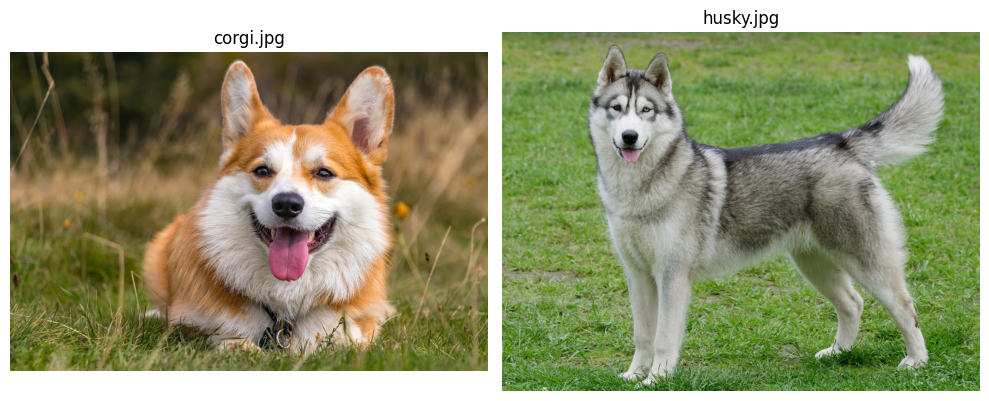

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

uris = results["uris"][0]
metadatas = results["metadatas"][0]

fig, axes = plt.subplots(1, len(uris), figsize=(5 * len(uris), 5))
if len(uris) == 1:
    axes = [axes]

for ax, uri, meta in zip(axes, uris, metadatas):
    ax.imshow(Image.open(uri))
    ax.set_title(meta.get("filename", uri))
    ax.axis("off")

plt.tight_layout()
plt.show()
